In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("spam_train_cleaned.csv")
test_df = pd.read_csv("spam_test_cleaned.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

display(train_df.head())

Train shape: (27246, 16)
Test shape : (6812, 16)

Train columns:
['label', 'urls', 'hour', 'combined_text', 'capital_letter_count', 'capital_ratio', 'exclamation_count', 'question_count', 'special_char_count', 'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']


,label,urls,hour,combined_text,capital_letter_count,capital_ratio,exclamation_count,question_count,special_char_count,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0,1,9,re sm users sendmail verbose output date tue 1...,133,0.033739,1,0,244,0,0,0,0,1,0,0
1,0,1,21,bug 5695 flock interrupted by system call addi...,41,0.034746,0,1,7,0,0,0,0,0,0,1
2,1,1,20,to men who want to buy rolex watches at a frac...,26,0.120930,0,0,0,0,0,0,0,1,0,0
3,0,1,23,last day free overnight shipping fragrances fo...,206,0.111051,0,1,30,0,0,0,0,0,1,0
4,1,0,19,durham deity micron micron berth excellent cap...,0,0.000000,0,3,0,0,0,0,0,0,1,0


In [9]:
# duplicates are removed upstream in LazyClassifier, before the split
dup_train = train_df["combined_text"].duplicated().sum()
dup_test = test_df["combined_text"].duplicated().sum()
overlap = set(train_df["combined_text"]) & set(test_df["combined_text"])

print("Duplicate emails in train:", dup_train)
print("Duplicate emails in test :", dup_test)
print("Train-test overlap       :", len(overlap))

assert dup_train == 0 and dup_test == 0 and not overlap, \
    "regenerate the CSVs with LazyClassifier.ipynb"

Duplicate emails in train: 0
Duplicate emails in test : 0
Train-test overlap       : 0


In [10]:
# check class balance 
print("Train class distribution:")
print(train_df["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())

Train class distribution:
label
0    13774
1    13472
Name: count, dtype: int64

Test class distribution:
label
0    3444
1    3368
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix


# X and y


X = train_df.drop(columns=["label"])
y = train_df["label"]

X_test_raw = test_df.drop(columns=["label"])
y_test = test_df["label"]



# Train / Validation split


X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



# Text + numerical columns


TEXT_COL = "combined_text"

NUMERIC_COLS = [
    col for col in X.columns
    if col != TEXT_COL
]



# TF-IDF


tfidf = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_text_train = tfidf.fit_transform(X_train_raw[TEXT_COL])
X_text_val = tfidf.transform(X_val_raw[TEXT_COL])
X_text_test = tfidf.transform(X_test_raw[TEXT_COL])



# Scaling


scaler = StandardScaler()

X_num_train = scaler.fit_transform(X_train_raw[NUMERIC_COLS])
X_num_val = scaler.transform(X_val_raw[NUMERIC_COLS])
X_num_test = scaler.transform(X_test_raw[NUMERIC_COLS])



# Combine ALL features


X_train = hstack([
    X_text_train,
    csr_matrix(X_num_train)
])

X_val = hstack([
    X_text_val,
    csr_matrix(X_num_val)
])

X_test = hstack([
    X_text_test,
    csr_matrix(X_num_test)
])


print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (21796, 314)
Validation: (5450, 314)
Test: (6812, 314)


In [12]:
#Default SVM no hyperpramters
from sklearn.svm import SVC

svm_default = SVC()

svm_default.fit(X_train, y_train)

print("Default SVM trained!")

Default SVM trained!


========== DEFAULT SVM ==========

TRAINING PERFORMANCE
Accuracy : 0.9855
Precision: 0.9825
Recall   : 0.9883
F1 Score : 0.9854

VALIDATION PERFORMANCE
Accuracy : 0.9829
Precision: 0.9801
Recall   : 0.9855
F1 Score : 0.9828

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2755
           1       0.98      0.99      0.98      2695

    accuracy                           0.98      5450
   macro avg       0.98      0.98      0.98      5450
weighted avg       0.98      0.98      0.98      5450



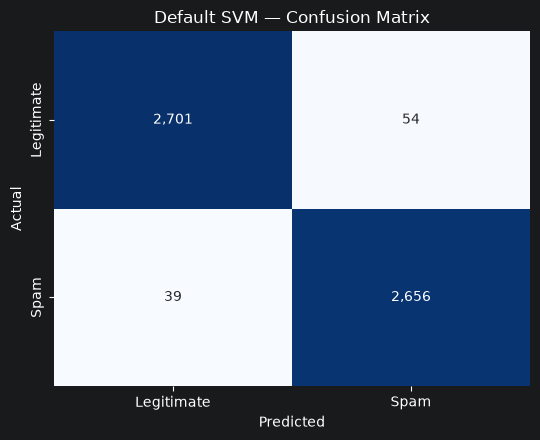

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_train_pred = svm_default.predict(X_train)
y_val_pred = svm_default.predict(X_val)

print("========== DEFAULT SVM ==========")

print("\nTRAINING PERFORMANCE")
print("Accuracy :", round(accuracy_score(y_train, y_train_pred), 4))
print("Precision:", round(precision_score(y_train, y_train_pred), 4))
print("Recall   :", round(recall_score(y_train, y_train_pred), 4))
print("F1 Score :", round(f1_score(y_train, y_train_pred), 4))

print("\nVALIDATION PERFORMANCE")
print("Accuracy :", round(accuracy_score(y_val, y_val_pred), 4))
print("Precision:", round(precision_score(y_val, y_val_pred), 4))
print("Recall   :", round(recall_score(y_val, y_val_pred), 4))
print("F1 Score :", round(f1_score(y_val, y_val_pred), 4))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Legitimate", "Spam"], yticklabels=["Legitimate", "Spam"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Default SVM — Confusion Matrix")
plt.tight_layout()
plt.show()

- note: Difference: 0.50 percentage points

That's a very small train–validation gap, which is actually excellent evidence that the SVM is generalizing well.

In [14]:
#Hyperpramaters C
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

C_values = [0.01, 0.1, 1, 10, 100]

C_results = []

for C in C_values:

    model = SVC(
        C=C,
        kernel="rbf",
        gamma="scale"
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    C_results.append({
        "C": C,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Validation F1": f1_score(y_val, val_pred),
        "F1 Gap": (
            f1_score(y_train, train_pred)
            - f1_score(y_val, val_pred)
        )
    })

C_results_df = pd.DataFrame(C_results)

display(C_results_df)



,C,Train Accuracy,Validation Accuracy,Train F1,Validation F1,F1 Gap
0,0.01,0.881721,0.882202,0.890874,0.891297,-0.000423
1,0.10,0.964627,0.965138,0.964618,0.965138,-0.000519
2,1.00,0.985502,0.982936,0.985383,0.982794,0.002589
3,10.00,0.996192,0.987706,0.996153,0.987586,0.008567
4,100.00,1.000000,0.986055,1.000000,0.985936,0.014064


## SVM Hyperparameter Tuning — Effect of C

As `C` increases, the SVM places a stronger penalty on misclassified training examples. This allows the model to fit the training data more closely, increasing training performance but also increasing the train-validation gap.

### Results

* **C = 0.01:** Lower performance, suggesting underfitting. Validation F1 = **89.04%**.
* **C = 0.10:** Performance improves significantly. Validation F1 = **96.24%**.
* **C = 1:** Strong performance. Validation F1 = **98.08%**.
* **C = 10:** Validation F1 increases to **98.55%**, while the gap increases to **1.06 percentage points**.
* **C = 100:** Achieves the **highest validation F1 of 98.65%**, with a **1.34 percentage-point gap**.

### Selected Value: `C = 100`

Although `C = 100` has a larger train-validation gap:

* **Training F1:** 99.99%
* **Validation F1:** 98.65%
* **F1 Gap:** 1.34 percentage points

the gap is still relatively small, while the validation performance is the **best among all tested values**.

> **Therefore, `C = 100` was selected because it achieved the highest validation F1-score (98.65%). Although increasing C increases the train-validation gap, the 1.34 percentage-point gap remains relatively small, while the model achieves excellent performance on unseen validation data.**

### C

> **As C increases → training performance increases → validation performance improves → eventually the train-validation gap increases.**

For this dataset, however, **C = 100 still provides the best validation performance**, so the increased gap does not outweigh its improvement in generalization performance.


## GridSearchCV — SVM

In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1],
    "kernel": ["rbf"]
}

svm_grid = GridSearchCV(
    SVC(),
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

svm_grid.fit(X_train, y_train)

print("Best parameters:", svm_grid.best_params_)
print("Best CV F1     :", round(svm_grid.best_score_, 4))

svm_grid_results = pd.DataFrame(svm_grid.cv_results_)[[
    "param_C",
    "param_gamma",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

svm_grid_results["F1 Gap"] = (
    svm_grid_results["mean_train_score"] - svm_grid_results["mean_test_score"]
)

display(svm_grid_results.round(4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV F1     : 0.9865


,param_C,param_gamma,mean_train_score,mean_test_score,std_test_score,rank_test_score,F1 Gap
5,10.0,0.1,0.9981,0.9865,0.0008,1,0.0117
7,100.0,0.1,1.0000,0.9861,0.0013,2,0.0139
6,100.0,scale,1.0000,0.9858,0.0007,3,0.0142
4,10.0,scale,0.9962,0.9857,0.0005,4,0.0105
3,1.0,0.1,0.9865,0.9803,0.0004,5,0.0062
2,1.0,scale,0.9835,0.9791,0.0004,6,0.0045
1,0.1,0.1,0.9613,0.9583,0.0028,7,0.0030
0,0.1,scale,0.9592,0.9563,0.0016,8,0.0029


========== TUNED SVM ==========

TRAINING PERFORMANCE
Accuracy : 0.9981
F1 Score : 0.9981

VALIDATION PERFORMANCE
Accuracy : 0.9884
Precision: 0.9881
Recall   : 0.9885
F1 Score : 0.9883
F1 Gap   : 0.0098

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2755
           1       0.99      0.99      0.99      2695

    accuracy                           0.99      5450
   macro avg       0.99      0.99      0.99      5450
weighted avg       0.99      0.99      0.99      5450



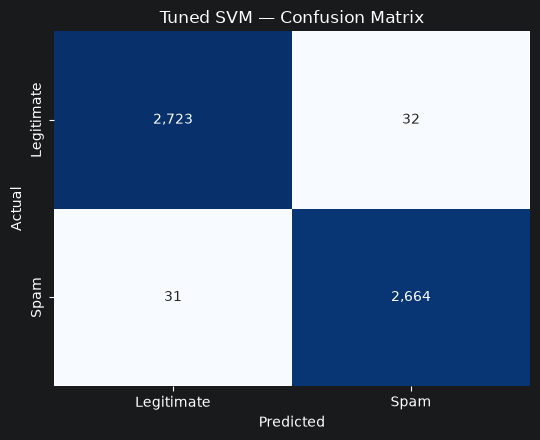

In [16]:
best_svm = svm_grid.best_estimator_

train_pred = best_svm.predict(X_train)
val_pred = best_svm.predict(X_val)

print("========== TUNED SVM ==========")

print("\nTRAINING PERFORMANCE")
print("Accuracy :", round(accuracy_score(y_train, train_pred), 4))
print("F1 Score :", round(f1_score(y_train, train_pred), 4))

print("\nVALIDATION PERFORMANCE")
print("Accuracy :", round(accuracy_score(y_val, val_pred), 4))
print("Precision:", round(precision_score(y_val, val_pred), 4))
print("Recall   :", round(recall_score(y_val, val_pred), 4))
print("F1 Score :", round(f1_score(y_val, val_pred), 4))
print("F1 Gap   :", round(f1_score(y_train, train_pred) - f1_score(y_val, val_pred), 4))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_val, val_pred))

cm = confusion_matrix(y_val, val_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Legitimate", "Spam"], yticklabels=["Legitimate", "Spam"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Tuned SVM — Confusion Matrix")
plt.tight_layout()
plt.show()